In [1]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import networkx.algorithms.community as nx_comm
import pickle
import time
import random
import math

In [2]:
stage_labels = ['L1-0', 'L1-5', 'L1-8', 'L1-16', 'L2', 'L3', 'Ad-45-1', 'Ad-45-2']

In [3]:
stage_labels_plot = ['L1$_{0h}$', 'L1$_{5h}$', 'L1$_{8h}$', 'L1$_{16h}$', 'L2', 'L3', 'Ad$^{1}$', 'Ad$^{2}$']

In [4]:
# It tells Matplotlib's mathtext engine to render math upright (roman) instead of the default italics — 
# without needing to wrap your labels in \mathrm{} or edit the list.
plt.rcParams['mathtext.default'] = 'regular' 

In [3]:
with open('data/processed/all_c_elegans_weighted_graphs.pkl', 'rb') as file:
    all_c_elegans_weighted_graphs = pickle.load(file)

In [9]:
def kin_k_core_decomposition(G):
    k_cores = {}
    G_k_core = G.copy()

    while G_k_core.number_of_nodes() > 0:
        min_k = min(dict(G_k_core.in_degree()).values())
        k_cores[min_k] = list(G_k_core.nodes())
        
        to_remove = [node for node, in_degree in G_k_core.in_degree() if in_degree <= min_k]
        
        while to_remove:
            G_k_core.remove_nodes_from(to_remove)
            to_remove = [node for node, in_degree in G_k_core.in_degree() if in_degree <= min_k]

    return k_cores

def kout_k_core_decomposition(G):
    k_cores = {}
    G_k_core = G.copy()

    while G_k_core.number_of_nodes() > 0:
        min_k = min(dict(G_k_core.out_degree()).values())
        k_cores[min_k] = list(G_k_core.nodes())
        
        to_remove = [node for node, out_degree in G_k_core.out_degree() if out_degree <= min_k]
        
        while to_remove:
            G_k_core.remove_nodes_from(to_remove)
            to_remove = [node for node, out_degree in G_k_core.out_degree() if out_degree <= min_k]

    return k_cores

In [11]:
def k_core_number_directed(k_cores_directed_dict):
    
    corenumber_dict = {}
    for k, nodes in k_cores_directed_dict.items():
        for node in nodes:
            corenumber_dict[node] = k
            
    return corenumber_dict

In [13]:
def greedy_scs_cleaned_directed(G_input, direction, seed=None):
    
    """
    Differs from the undirected version:
    - Supportive neighbors depend on core type:
        'in'  → predecessors, 'out' → successors.
    - Only one endpoint’s CS changes per deletion:
        'in'  → head (v), 'out' → tail (u).
    - Edge deletability:
        'in'  → (u,v) deletable if core[u] ≥ core[v] and CS[v] > 1
        'out' → (u,v) deletable if core[v] ≥ core[u] and CS[u] > 1
      (no same-/cross-shell cases).

    Rest of the logic (local CS updates, candidate set R, greedy deletions)
    is the same as the undirected version.
    """
    
    if seed is not None:
        random.seed(seed)

    G = G_input.copy()

    if direction == 'in':
        corefunc = kin_k_core_decomposition
        support_neighbors = G.predecessors   # supporters of v are predecessors (u->v)
        affected_by_removal = 'head'         # removing (u->v) affects v
    elif direction == 'out':
        corefunc = kout_k_core_decomposition
        support_neighbors = G.successors     # supporters of u are successors (u->w)
        affected_by_removal = 'tail'         # removing (u->v) affects u
    else:
        raise ValueError("direction must be 'in' or 'out'.")

    kcores = corefunc(G)
    core = k_core_number_directed(kcores)

    # --- CS init (counts supportive neighbors in the chosen direction) ---
    CS = {}
    for v in G.nodes():
        kv = core[v]
        dkv = sum(1 for u in support_neighbors(v) if core[u] >= kv)
        CS[v] = dkv - kv + 1

    # --- helper: directed deletability predicate ---
    if direction == 'in':
        # (u->v) supportive iff core[u] >= core[v]; deletable iff supportive and CS[v] > 1
        def deletable(u, v):
            return core[u] >= core[v] and CS[v] > 1
    else:  # 'out'
        # (u->v) supportive iff core[v] >= core[u]; deletable iff supportive and CS[u] > 1
        def deletable(u, v):
            return core[v] >= core[u] and CS[u] > 1

    # --- Initialize R with deletable edges (directed rule) ---
    R = set()
    for u, v in G.edges():
        if deletable(u, v):
            R.add((u, v))

    # --- main loop ---
    while R:
        u, v = random.choice(list(R))
        G.remove_edge(u, v)
        R.discard((u, v))

        # Update CS locally: only the endpoint whose support depends on (u->v)
        if direction == 'in':
            # removing (u->v) reduces v's supportive in-neighbors by 1 (since core[u] >= core[v] for deletable)
            CS[v] -= 1
            # Clean R: only edges into v can lose deletability
            for w in list(G.predecessors(v)):
                e = (w, v)
                if e in R and not deletable(*e):
                    R.discard(e)
        else:  # 'out'
            # removing (u->v) reduces u's supportive out-neighbors by 1 (since core[v] >= core[u] for deletable)
            CS[u] -= 1
            # Clean R: only edges out of u can lose deletability
            for w in list(G.successors(u)):
                e = (u, w)
                if e in R and not deletable(*e):
                    R.discard(e)

    return G


In [15]:
def describe_network_directed(G):
    
    isdir = nx.is_directed(G)
    iswei = nx.is_weighted(G)
    iscon = nx.is_weakly_connected(G)
    ifloops = bool(list(nx.selfloop_edges(G)))

    return (f'directed: {isdir}; weighted: {iswei}; weakly connected: {iscon}; loops: {ifloops}')
        

In [17]:
def prune_for_SCS_directed(original_g, direction, n=100):
    
    g = original_g.copy()

    if 'loops: True' in describe_network_directed(original_g):
        loops = list(nx.selfloop_edges(original_g))
        original_g.remove_edges_from(loops)
        
    if 'weakly connected: False' in describe_network_directed(original_g):
        lcc_nodes = max(list(nx.weakly_connected_components(original_g)), key=len)
        g = nx.subgraph(original_g, lcc_nodes)

    if direction == 'in':
        corefunc = kin_k_core_decomposition
    elif direction == 'out':
        corefunc = kout_k_core_decomposition
        
    kcores = corefunc(g)
    core = k_core_number_directed(kcores)
    
    kstar = max(core.values())
    
    start = time.time()
    g_SCSs = [greedy_scs_cleaned_directed(g, direction) for i in range(n)]
    end = time.time()
    print(f"Runtime: {end - start:.4f} seconds")

    return g_SCSs, core, kstar

In [19]:
def core_centralized_score_on_scs_directed(H_scs, core, kstar, neighbortype):
    
    """
    Core Centralized Score (CE) for a directed skeletal core subgraph.

    Differs from the undirected version only in supportive neighbors:
        'in'  → predecessors with core ≥ κ(v)
        'out' → successors with core ≥ κ(v)

    Uses original core numbers (core, kstar) from the full graph.
    """
    
    #if direction == 'in':
    #    neighborsfunc = H_scs.predecessors
    #elif direction == 'out':
    #   neighborsfunc = H_scs.successors

    if neighbortype == 'in':
        neighborsfunc = H_scs.predecessors
    elif neighbortype == 'out':
        neighborsfunc = H_scs.successors
    elif neighbortype == 'both':
        neighborsfunc = lambda n: set(H_scs.predecessors(n)) | set(H_scs.successors(n))

    V = list(H_scs.nodes())
    V_bar = [v for v in V if core[v] < kstar]
    if not V_bar:
        return 0.0  # Entire graph is main core

    total = 0.0
    for v in V_bar:
        kv = core[v]
        gap = kstar - kv 

        # Supportive neighbors: same or higher core number
        supportive_neighbors = [u for u in neighborsfunc(v) if core[u] >= kv]
        if not supportive_neighbors:
            continue  # contributes 0

        inner_sum = sum((core[u] - kv) / gap for u in supportive_neighbors)
        total += inner_sum / len(supportive_neighbors)

    return total / len(V_bar)


In [21]:
def show_n_stow_results_directed(original_g, g_SCSs, neighbortype, core_number, kstar):
    
    ce = []
    sizes = []
    for SCS in g_SCSs:
        ce.append(core_centralized_score_on_scs_directed(SCS, core_number, kstar, neighbortype))
        sizes.append(SCS.number_of_edges())

    print("CCS:", np.mean(ce), '|',  "Degeneracy (k*):", kstar)
    
    return return_experiment_results(original_g, kstar, np.mean(ce), np.std(ce), np.mean(sizes))

In [23]:
start = time.time()
test_SCSs = [greedy_scs_cleaned_directed(all_c_elegans_weighted_graphs[7], 'in') for i in range(100)]
end = time.time()
print(f"Runtime: {end - start:.4f} seconds")

Runtime: 2.1368 seconds


In [24]:
start = time.time()
test_SCSs = [greedy_scs_cleaned_directed(all_c_elegans_weighted_graphs[7], 'out') for i in range(100)]
end = time.time()
print(f"Runtime: {end - start:.4f} seconds")

Runtime: 1.2028 seconds


In [23]:
def check_SCS_minimal_directed(graph, SCS, direction):
    
    '''Takes the original graph and its supposed SCS and returns True if the SCS is actually minimal'''
    
    if direction == 'in':
        corefunc = kin_k_core_decomposition
        neighbors = SCS.predecessors   # supporters of v are predecessors (u->v)
    elif direction == 'out':
        corefunc = kout_k_core_decomposition
        neighbors = SCS.successors     # supporters of u are successors (u->w)
    else:
        raise ValueError("direction must be 'in' or 'out'.")

    kcores = corefunc(graph)
    core = k_core_number_directed(kcores)

    CS = {}#lol actually I should have run the test for core validity before this since I am using core org of the main graph on the SCS but it's alright
    for v in SCS.nodes():
        kv = core[v] 
        dkv = sum(1 for u in neighbors(v) if core[u] >= kv)
        CS[v] = dkv - kv + 1

    edg_cs = set()
    for u,v in SCS.edges():
        edg_cs.add((CS[u], CS[v]))
    each_edge_indispensible = all([1 in edg for edg in edg_cs])

    return each_edge_indispensible

In [57]:
def check_SCS_core_valid_directed(graph, SCS, direction): 
    
    '''Takes the original graph and its supposed SCS and returns True if the SCS is Core-Valid i.e. the Core numbers of all the nodes in the SCS
       are the same as the original graph. '''
    
    if direction == 'in':
        corefunc = kin_k_core_decomposition
        neighbors = SCS.predecessors   # supporters of v are predecessors (u->v)
    elif direction == 'out':
        corefunc = kout_k_core_decomposition
        neighbors = SCS.successors     # supporters of u are successors (u->w)
    else:
        raise ValueError("direction must be 'in' or 'out'.")

    kcores = corefunc(graph)
    emp_cn = k_core_number_directed(kcores)

    kcores_SCS = corefunc(SCS)
    scs_cn = k_core_number_directed(kcores_SCS)

    compare = [scs_cn[k] == emp_cn[k] for k in scs_cn]
    core_valid = all(compare)

    return core_valid

### Final Run

There are 4 types of CE that we can calculate on the basis of k-core decomposition. For each of the in-degree core and out-degree core, we can have 
neighbors as only predecessors of non core nodes or their successors. 

#### $k_{in}$ core

Generating SCSs...

In [57]:
celegans_SCSs_kin = {}

In [59]:
celegans_SCSs_CE_results_kin_kin = {}

In [63]:
for idx, graph in enumerate(all_c_elegans_weighted_graphs):
    SCSs, core_number, kstar = prune_for_SCS_directed(graph, 'in', 5000)
    print(all([check_SCS_minimal_directed(graph, SCS, 'in') for SCS in SCSs]))
    print(all([check_SCS_core_valid_directed(graph, SCS, 'in') for SCS in  SCSs]))
    celegans_SCSs_kin[idx] = (SCSs, core_number, kstar)

Runtime: 22.5765 seconds
True
True
Runtime: 33.9961 seconds
True
True
Runtime: 30.5602 seconds
True
True
Runtime: 39.8229 seconds
True
True
Runtime: 56.8202 seconds
True
True
Runtime: 59.4635 seconds
True
True
Runtime: 159.9244 seconds
True
True
Runtime: 109.9173 seconds
True
True


In [64]:
#with open('data/processed/C_elegans_SCSs_5000_kin.pkl', 'wb') as file:
    #pickle.dump(celegans_SCSs_kin, file)

In [194]:
with open('data/processed/C_elegans_SCSs_5000_kin.pkl', 'rb') as file:
    celegans_SCSs_kin = pickle.load(file)

Calculating CE for SCSs of $k_{in}$ core using in-neighbors

In [116]:
for idx, graph in enumerate(all_c_elegans_weighted_graphs):
    SCSs, core_number, kstar = celegans_SCSs_kin[idx]
    celegans_SCSs_CE_results_kin_kin[idx] = show_n_stow_results_directed(graph, SCSs, 'in', core_number, kstar)
    print(idx, ' done')

CCS: 0.1539918604651163 | Degeneracy (k*): 3
0  done
CCS: 0.13765730337078652 | Degeneracy (k*): 3
1  done
CCS: 0.29836953642384106 | Degeneracy (k*): 3
2  done
CCS: 0.12636505376344084 | Degeneracy (k*): 3
3  done
CCS: 0.4789180722891566 | Degeneracy (k*): 3
4  done
CCS: 0.517504411764706 | Degeneracy (k*): 3
5  done
CCS: 0.8215746031746032 | Degeneracy (k*): 4
6  done
CCS: 0.6871838164251208 | Degeneracy (k*): 5
7  done


In [118]:
#with open('data/processed/C_elegans_SCSs_CE_results_kin_kin.pkl', 'wb') as file:
    #pickle.dump(celegans_SCSs_CE_results_kin_kin, file)

In [27]:
with open('data/processed/C_elegans_SCSs_CE_results_kin_kin.pkl', 'rb') as file:
    celegans_SCSs_CE_results_kin_kin = pickle.load(file)

Calculating CE for SCSs of $k_{in}$ core using out-neighbors

In [121]:
celegans_SCSs_CE_results_kin_kout = {}

In [123]:
for idx, graph in enumerate(all_c_elegans_weighted_graphs):
    SCSs, core_number, kstar = celegans_SCSs_kin[idx]
    celegans_SCSs_CE_results_kin_kout[idx] = show_n_stow_results_directed(graph, SCSs, 'out', core_number, kstar)
    print(idx, ' done')

CCS: 0.3070711808981285 | Degeneracy (k*): 3
0  done
CCS: 0.28808437384482916 | Degeneracy (k*): 3
1  done
CCS: 0.3974154094709559 | Degeneracy (k*): 3
2  done
CCS: 0.27180704734316213 | Degeneracy (k*): 3
3  done
CCS: 0.6113275948038412 | Degeneracy (k*): 3
4  done
CCS: 0.6463972459566577 | Degeneracy (k*): 3
5  done
CCS: 0.6614718741341509 | Degeneracy (k*): 4
6  done
CCS: 0.6370577954774209 | Degeneracy (k*): 5
7  done


In [125]:
#with open('data/processed/C_elegans_SCSs_CE_results_kin_kout.pkl', 'wb') as file:
    #pickle.dump(celegans_SCSs_CE_results_kin_kout, file)

In [29]:
with open('data/processed/C_elegans_SCSs_CE_results_kin_kout.pkl', 'rb') as file:
    celegans_SCSs_CE_results_kin_kout = pickle.load(file)

#### $k_{out}$ core 

Generating SCSs...

In [91]:
celegans_SCSs_kout = {}

In [93]:
for idx, graph in enumerate(all_c_elegans_weighted_graphs):
    SCSs, core_number, kstar = prune_for_SCS_directed(graph, 'out', 5000)
    print(all([check_SCS_minimal_directed(graph, SCS, 'out') for SCS in SCSs]))
    print(all([check_SCS_core_valid_directed(graph, SCS, 'out') for SCS in  SCSs]))
    celegans_SCSs_kout[idx] = (SCSs, core_number, kstar)

Runtime: 46.0609 seconds
True
True
Runtime: 31.0121 seconds
True
True
Runtime: 27.1733 seconds
True
True
Runtime: 32.3963 seconds
True
True
Runtime: 42.7079 seconds
True
True
Runtime: 38.3871 seconds
True
True
Runtime: 55.3617 seconds
True
True
Runtime: 67.5577 seconds
True
True


In [95]:
#with open('data/processed/C_elegans_SCSs_5000_kout.pkl', 'wb') as file:
    #pickle.dump(celegans_SCSs_kout, file)

In [ ]:
with open('data/processed/C_elegans_SCSs_5000_kout.pkl', 'rb') as file:
    celegans_SCSs_kout = pickle.load(file)

Calculating CE for SCSs of $k_{out}$ core using in-neighbors

In [98]:
celegans_SCSs_CE_results_kout_kin = {}

In [100]:
for idx, graph in enumerate(all_c_elegans_weighted_graphs):
    SCSs, core_number, kstar = celegans_SCSs_kout[idx]
    celegans_SCSs_CE_results_kout_kin[idx] = show_n_stow_results_directed(graph, SCSs, 'in', core_number, kstar)
    print(idx, ' done')

CCS: 0.5384050837136095 | Degeneracy (k*): 3
0  done
CCS: 0.6446890795295723 | Degeneracy (k*): 3
1  done
CCS: 0.6584765654158651 | Degeneracy (k*): 3
2  done
CCS: 0.7200858448325282 | Degeneracy (k*): 3
3  done
CCS: 0.6758108075244181 | Degeneracy (k*): 4
4  done
CCS: 0.6876193656526095 | Degeneracy (k*): 4
5  done
CCS: 0.7625564077573792 | Degeneracy (k*): 6
6  done
CCS: 0.8156836834627815 | Degeneracy (k*): 5
7  done


In [102]:
#with open('data/processed/C_elegans_SCSs_CE_results_kout_kin.pkl', 'wb') as file:
    #pickle.dump(celegans_SCSs_CE_results_kout_kin, file)

In [31]:
with open('data/processed/data/processed/C_elegans_SCSs_CE_results_kout_kin.pkl', 'rb') as file:
    celegans_SCSs_CE_results_kout_kin = pickle.load(file)

Calculating CE for SCSs of $k_{out}$ core using out-neighbors

In [105]:
celegans_SCSs_CE_results_kout_kout = {}

In [107]:
for idx, graph in enumerate(all_c_elegans_weighted_graphs):
    SCSs, core_number, kstar = celegans_SCSs_kout[idx]
    celegans_SCSs_CE_results_kout_kout[idx] = show_n_stow_results_directed(graph, SCSs, 'out', core_number, kstar)
    print(idx, ' done')

CCS: 0.2501532786885246 | Degeneracy (k*): 3
0  done
CCS: 0.2660728070175439 | Degeneracy (k*): 3
1  done
CCS: 0.25252719298245613 | Degeneracy (k*): 3
2  done
CCS: 0.23421623931623936 | Degeneracy (k*): 3
3  done
CCS: 0.24562683215130018 | Degeneracy (k*): 4
4  done
CCS: 0.27654346846846856 | Degeneracy (k*): 4
5  done
CCS: 0.29506502120441047 | Degeneracy (k*): 6
6  done
CCS: 0.2800949541284404 | Degeneracy (k*): 5
7  done


In [109]:
#with open('data/processed/C_elegans_SCSs_CE_results_kout_kout.pkl', 'wb') as file:
    #pickle.dump(celegans_SCSs_CE_results_kout_kout, file)

In [33]:
with open('data/processed/C_elegans_SCSs_CE_results_kout_kout.pkl', 'rb') as file:
    celegans_SCSs_CE_results_kout_kout = pickle.load(file)

In [184]:
len(kin_k_core_decomposition(all_c_elegans_weighted_graphs[7])[5])

150

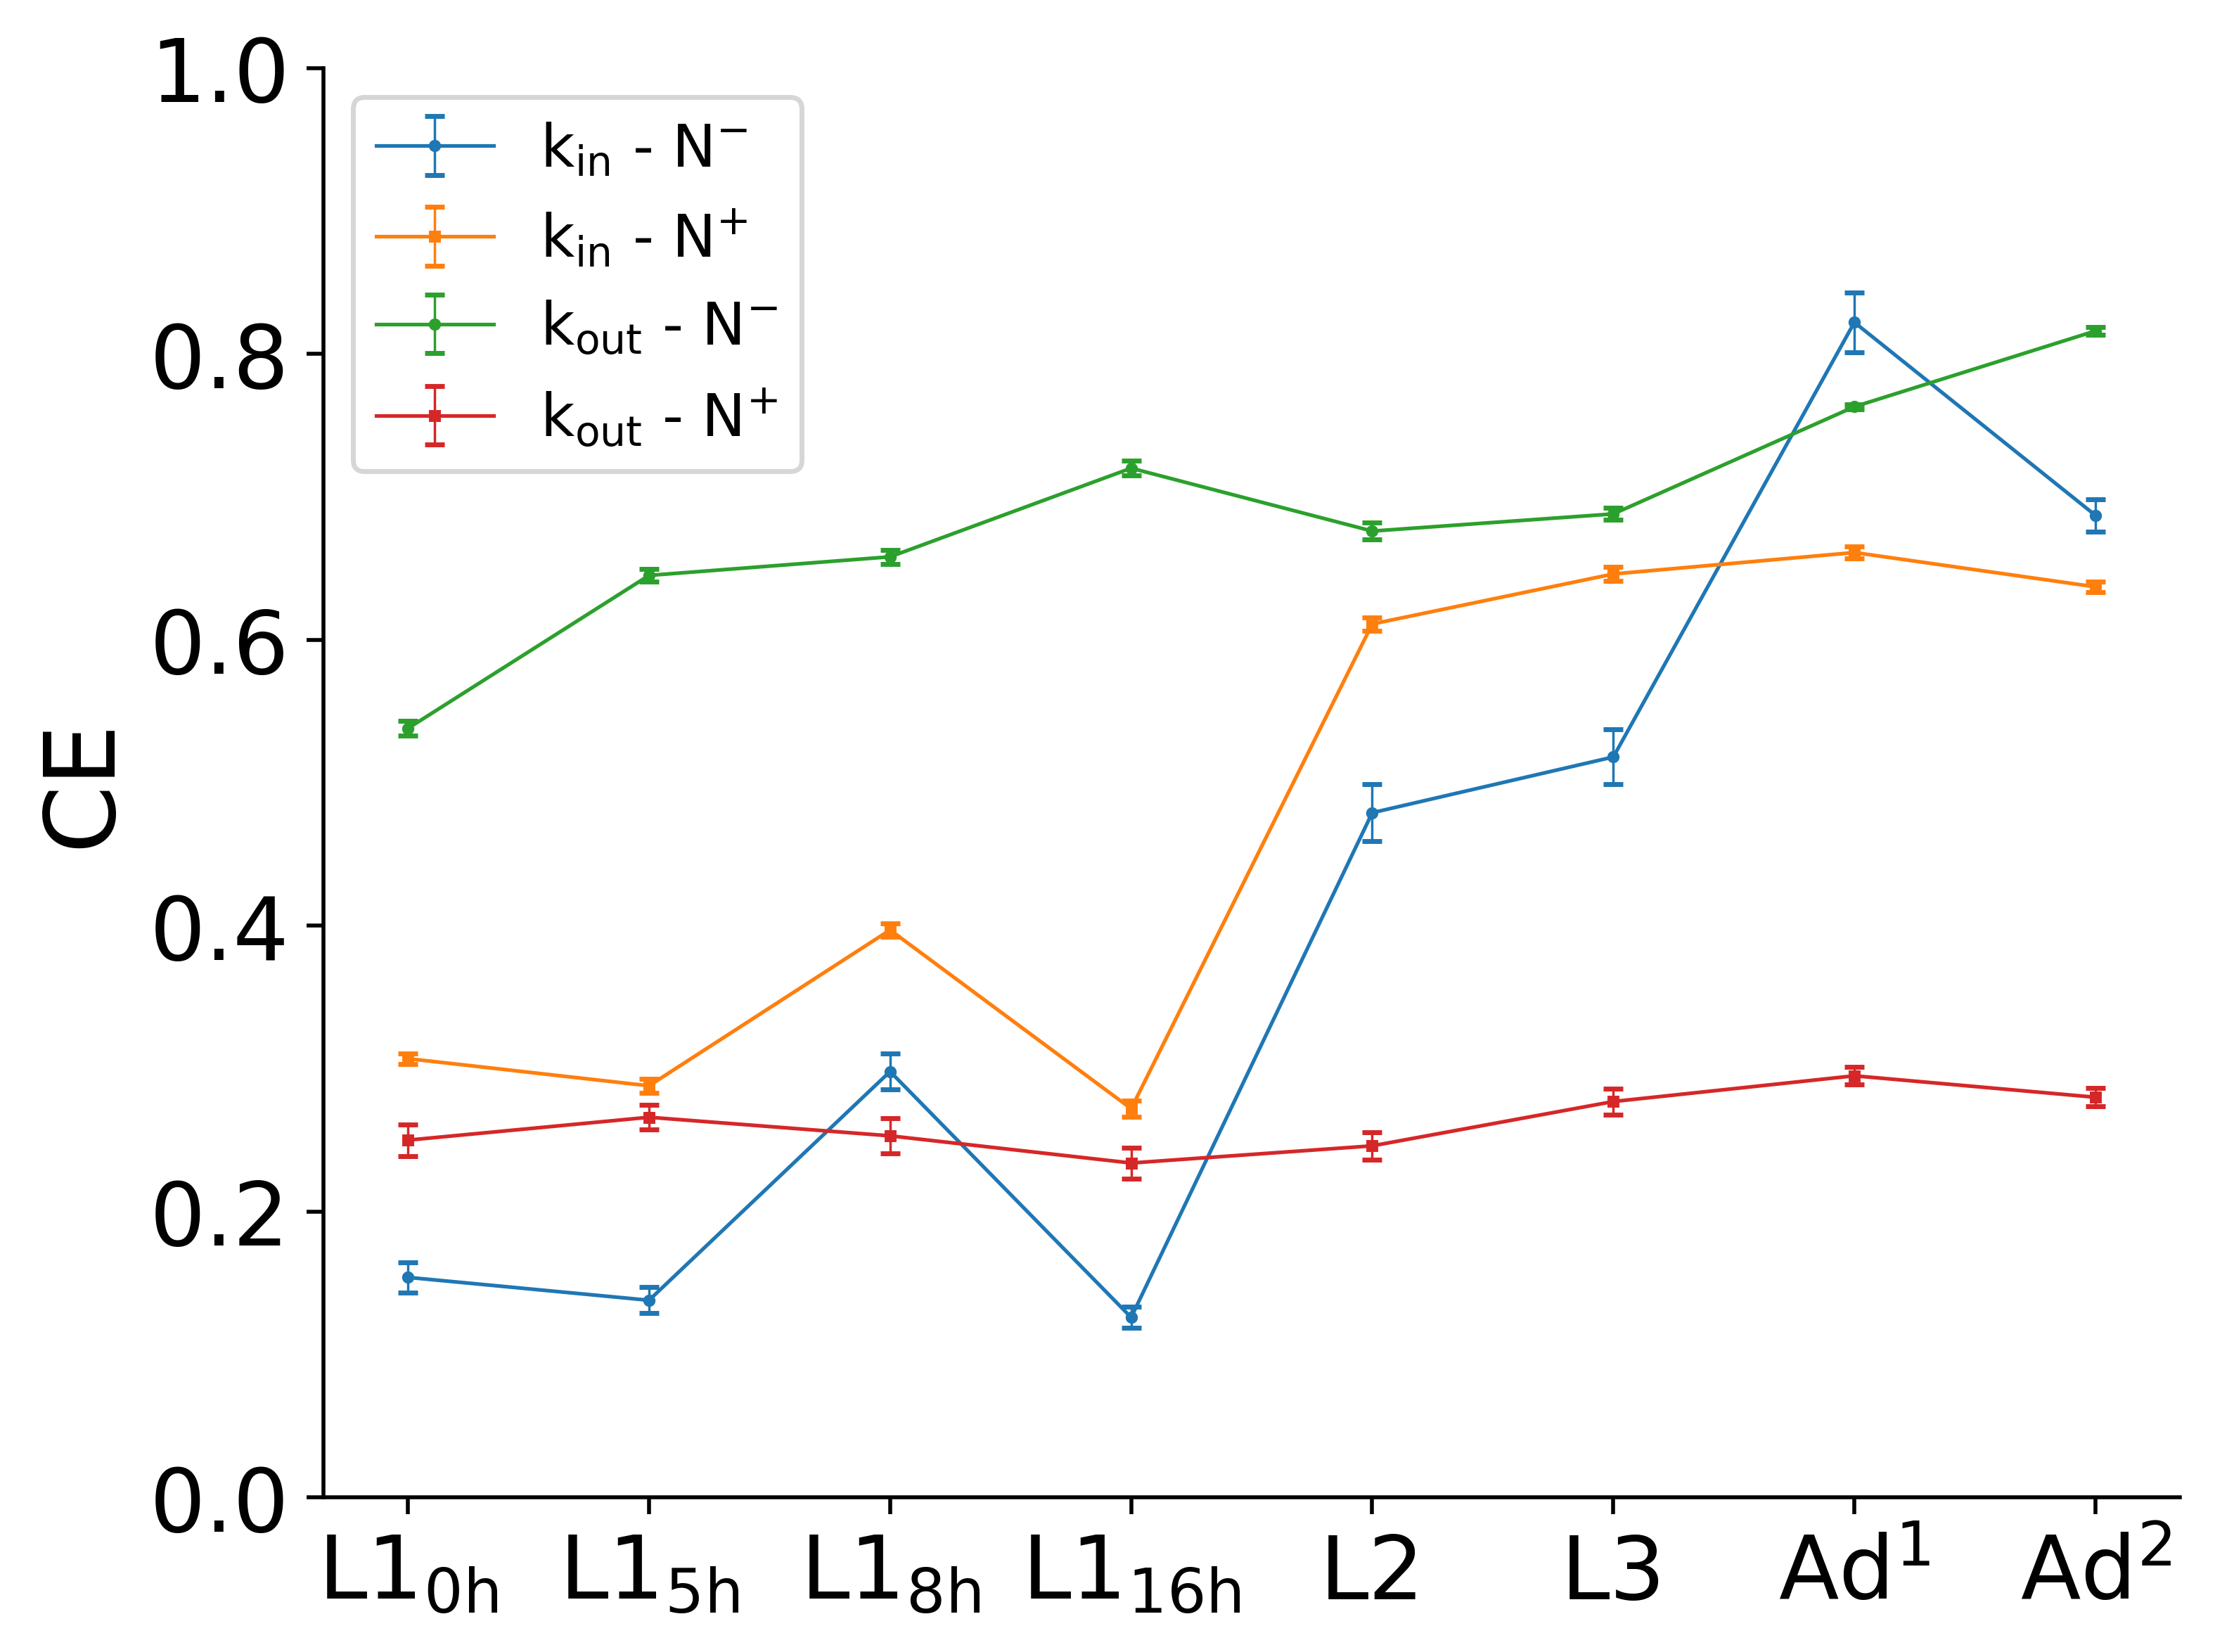

In [37]:
indices = sorted(celegans_SCSs_CE_results_kin_kin.keys())
stages = [stage_labels_plot[idx] for idx in indices]

# in-degree
    # in-neighbor
ce_vals_kin_kin = [float(celegans_SCSs_CE_results_kin_kin[i]["CE"]) for i in indices]
ce_stds_kin_kin = [float(celegans_SCSs_CE_results_kin_kin[i]["CE std"]) for i in indices]

    # out-neighbor
ce_vals_kin_kout = [float(celegans_SCSs_CE_results_kin_kout[i]["CE"]) for i in indices]
ce_stds_kin_kout = [float(celegans_SCSs_CE_results_kin_kout[i]["CE std"]) for i in indices]

# out-degree
    # in-neighbor
ce_vals_kout_kin = [float(celegans_SCSs_CE_results_kout_kin[i]["CE"]) for i in indices]
ce_stds_kout_kin = [float(celegans_SCSs_CE_results_kout_kin[i]["CE std"]) for i in indices]

    # out-neighbor
ce_vals_kout_kout = [float(celegans_SCSs_CE_results_kout_kout[i]["CE"]) for i in indices]
ce_stds_kout_kout = [float(celegans_SCSs_CE_results_kout_kout[i]["CE std"]) for i in indices]

fig, ax = plt.subplots(dpi=500)

ax.errorbar(
    stages, ce_vals_kin_kin, yerr=ce_stds_kin_kin,
    fmt='-o', capsize=2, elinewidth=0.5, markeredgewidth=1,
    markersize=1.5, linewidth=0.75, label="$k_{in}$ - $N^{-}$"
)

ax.errorbar(
    stages, ce_vals_kin_kout, yerr=ce_stds_kin_kout,
    fmt='-s', capsize=2, elinewidth=0.5, markeredgewidth=1,
    markersize=1.5, linewidth=0.75, label="$k_{in}$ - $N^{+}$"
)

ax.errorbar(
    stages, ce_vals_kout_kin, yerr=ce_stds_kout_kin,
    fmt='-o', capsize=2, elinewidth=0.5, markeredgewidth=1,
    markersize=1.5, linewidth=0.75, label="$k_{out}$ - $N^{-}$"
)

ax.errorbar(
    stages, ce_vals_kout_kout, yerr=ce_stds_kout_kout,
    fmt='-s', capsize=2, elinewidth=0.5, markeredgewidth=1,
    markersize=1.5, linewidth=0.75, label="$k_{out}$ - $N^{+}$"
)

ax.set_ylabel("CE", fontsize=20)
ax.set_ylim(0, 1)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
#ax.grid(True, axis='y', linestyle="--", alpha=1)
ax.legend(frameon=True, fontsize=12)
ax.tick_params(axis='both', labelsize=18)   # choose any size you like

plt.tight_layout()
plt.show()


In [23]:
def check_SCS_minimal_directed(graph, SCS, direction):
    
    '''Takes the original graph and its supposed SCS and returns True if the SCS is actually minimal'''
    
    if direction == 'in':
        corefunc = kin_k_core_decomposition
        neighbors = SCS.predecessors   # supporters of v are predecessors (u->v)
    elif direction == 'out':
        corefunc = kout_k_core_decomposition
        neighbors = SCS.successors     # supporters of u are successors (u->w)
    else:
        raise ValueError("direction must be 'in' or 'out'.")

    kcores = corefunc(graph)
    core = k_core_number_directed(kcores)

    CS = {}#lol actually I should have run the test for core validity before this since I am using core org of the main graph on the SCS but it's alright
    for v in SCS.nodes():
        kv = core[v] 
        dkv = sum(1 for u in neighbors(v) if core[u] >= kv)
        CS[v] = dkv - kv + 1

    edg_cs = set()
    for u,v in SCS.edges():
        edg_cs.add((CS[u], CS[v]))
    each_edge_indispensible = all([1 in edg for edg in edg_cs])

    return each_edge_indispensible

In [25]:
with open('data/processed/C_elegans_SCSs_5000_kin.pkl', 'rb') as file:
    celegans_SCSs_kin = pickle.load(file)

**Data structure**:

celegans_SCSs_kin -> 

                   { 0: ([nx.digraph, nx.digraph, ..., nx.digraph], {node: k_num, node: k_num, ... node: k_num}, kstar)
                     1: ([nx.digraph, nx.digraph, ..., nx.digraph], {node: k_num, node: k_num, ... node: k_num}, kstar) 
                     ...
                     7: ([nx.digraph, nx.digraph, ..., nx.digraph], {node: k_num, node: k_num, ... node: k_num}, kstar) }

In [39]:
each_edge_indispensible_stages = {}
for stage, data in celegans_SCSs_kin.items():
    graph = all_c_elegans_weighted_graphs[stage]
    each_edge_indispensible_stages[stage] = []
    for SCS in data[0]: # data is a tuple of size 3 having list of 5000 SCS graphs, dictionary of core numbers of original graph and kstar value
        each_edge_indispensible_stages[stage].append(check_SCS_minimal_directed(graph, SCS, 'in'))
        

**Data structure**: 

each_edge_indispensible_stages -> 

                                { 0: [bool, bool, ..., bool]
                                  1: [bool, bool, ..., bool], 
                                  ...
                                  7: [bool, bool, ..., bool] }


In [43]:
for stage, vals in each_edge_indispensible_stages.items():
    print(len(vals))

5000
5000
5000
5000
5000
5000
5000
5000


In [45]:
# all the SCSs of each stage are minimal
for stage, vals in each_edge_indispensible_stages.items():
    print(all(vals))

True
True
True
True
True
True
True
True


In [63]:
[check_SCS_minimal_directed(all_c_elegans_weighted_graphs[6], graph, 'in') for graph in celegans_SCSs_kin[6][0][:10]]

[True, True, True, True, True, True, True, True, True, True]

In [65]:
# as it should be, the original graph is not minimal
for graph in all_c_elegans_weighted_graphs:
    print(check_SCS_minimal_directed(graph, graph, 'in'))

False
False
False
False
False
False
False
False


In [57]:
def check_SCS_core_valid_directed(graph, SCS, direction): 
    
    '''Takes the original graph and its supposed SCS and returns True if the SCS is Core-Valid i.e. the Core numbers of all the nodes in the SCS
       are the same as the original graph. '''
    
    if direction == 'in':
        corefunc = kin_k_core_decomposition
        neighbors = SCS.predecessors   # supporters of v are predecessors (u->v)
    elif direction == 'out':
        corefunc = kout_k_core_decomposition
        neighbors = SCS.successors     # supporters of u are successors (u->w)
    else:
        raise ValueError("direction must be 'in' or 'out'.")

    kcores = corefunc(graph)
    emp_cn = k_core_number_directed(kcores)

    kcores_SCS = corefunc(SCS)
    scs_cn = k_core_number_directed(kcores_SCS)

    compare = [scs_cn[k] == emp_cn[k] for k in scs_cn]
    core_valid = all(compare)

    return core_valid

**Data structure**: 

core_valid_stages -> 

                                { 0: [bool, bool, ..., bool]
                                  1: [bool, bool, ..., bool], 
                                  ...
                                  7: [bool, bool, ..., bool] }


In [67]:
core_valid_stages = {}
for stage, data in celegans_SCSs_kin.items():
    graph = all_c_elegans_weighted_graphs[stage]
    core_valid_stages[stage] = []
    for SCS in data[0]:
        core_valid_stages[stage].append(check_SCS_core_valid_directed(graph, SCS, 'in'))

In [69]:
# all the SCS for each stage graph are core valid
for stage, vals in core_valid_stages.items():
    print(all(vals))

True
True
True
True
True
True
True
True


**Out-degree**

In [128]:
with open('data/processed/C_elegans_SCSs_5000_kout.pkl', 'rb') as file:
    celegans_SCSs_kout = pickle.load(file)

In [137]:
each_edge_indispensible_stages = {}
for stage, data in celegans_SCSs_kout.items():
    graph = all_c_elegans_weighted_graphs[stage]
    each_edge_indispensible_stages[stage] = []
    for SCS in data[0]:
        each_edge_indispensible_stages[stage].append(check_SCS_minimal_directed(graph, SCS, 'out'))

In [139]:
for stage, vals in each_edge_indispensible_stages.items():
    print(len(vals))

5000
5000
5000
5000
5000
5000
5000
5000


In [141]:
# all the SCSs of each stage are minimal
for stage, vals in each_edge_indispensible_stages.items():
    print(all(vals))

True
True
True
True
True
True
True
True


In [143]:
# as it should be, the original graph is not minimal
for graph in all_c_elegans_weighted_graphs:
    print(check_SCS_minimal_directed(graph, graph, 'out'))

False
False
False
False
False
False
False
False


In [145]:
core_valid_stages = {}
for stage, data in celegans_SCSs_kout.items():
    graph = all_c_elegans_weighted_graphs[stage]
    core_valid_stages[stage] = []
    for SCS in data[0]:
        core_valid_stages[stage].append(check_SCS_core_valid_directed(graph, SCS, 'out'))

In [147]:
# all the SCS for each stage graph are core valid
for stage, vals in core_valid_stages.items():
    print(all(vals))

True
True
True
True
True
True
True
True
